In [1]:
from sklearn.datasets import fetch_openml
boston = fetch_openml(name='boston', version=1)
print(boston.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

In [2]:
X = boston.data.to_numpy().astype(float)
Y = boston.target.to_numpy().astype(float)

print (X.shape)
print(Y.shape)

(506, 13)
(506,)


In [3]:
import numpy as np
import torch
np.random.seed(123)
torch.random.manual_seed(123)
idx = np.random.permutation(len(X))

In [4]:
X = X[idx]
Y = Y[idx]

In [5]:
X_training = torch.Tensor(X[50:])
Y_training = torch.Tensor(Y[50:])
X_testing = torch.Tensor(X[:50])
Y_testing = torch.Tensor(Y[:50])

In [6]:
theta = torch.Tensor(13)
theta_0 = torch.Tensor(1)

theta.requires_grad_(True)
theta_0.requires_grad_(True)

theta.data.normal_(0,0.1) # inizializziamo il tensore con numeri casuali tratti da una distribuzione normale di media 0 e varianza 0.1
theta_0.data.normal_(0,0.1)

print(theta)
print(theta_0)

tensor([-0.0111,  0.0120, -0.0370, -0.0240, -0.1197,  0.0209, -0.0972, -0.0755,
         0.0324, -0.0109,  0.0210, -0.0391,  0.0235], requires_grad=True)
tensor([0.0665], requires_grad=True)


In [7]:
def linear_regression (input, theta, theta_0) :
    return input.mul(theta).sum(1)+theta_0

In [8]:
res = X_training.mul(theta)
print(res, res.shape)

tensor([[-6.2912e-04,  4.8145e-01, -2.3694e-01,  ...,  3.7018e-01,
         -1.5513e+01,  8.2946e-02],
        [-6.7404e-04,  0.0000e+00, -9.0930e-02,  ...,  3.7439e-01,
         -1.5130e+01,  3.0899e-01],
        [-7.0198e-03,  0.0000e+00, -3.0088e-01,  ...,  4.4170e-01,
         -1.5513e+01,  1.9409e-01],
        ...,
        [-3.9141e-03,  0.0000e+00, -2.7279e-01,  ...,  4.1225e-01,
         -1.5513e+01,  1.8093e-01],
        [-1.0241e-01,  0.0000e+00, -6.6904e-01,  ...,  4.2487e-01,
         -1.5513e+01,  5.5454e-01],
        [-5.0783e-02,  0.0000e+00, -6.6904e-01,  ...,  4.2487e-01,
         -1.3863e+01,  1.6730e-01]], grad_fn=<MulBackward0>) torch.Size([456, 13])


In [9]:
res = res.sum(1)
print(res.shape)

torch.Size([456])


In [10]:
res = res+theta_0
print(res.shape)

torch.Size([456])


In [11]:
res = X_training.mul(theta).sum(1)+theta_0
print(res.shape)

torch.Size([456])


In [12]:
y = linear_regression(X_training, theta, theta_0)
print(y[:10])

tensor([-20.8190, -23.3360, -24.6247, -31.4600, -27.4998, -28.1950, -27.1047,
        -26.2724, -18.8539, -31.4594], grad_fn=<SliceBackward0>)


In [13]:
print(Y_training[:10])

tensor([32.4000, 29.6000, 20.4000, 12.3000, 19.1000, 14.9000, 17.8000,  8.8000,
        35.4000, 11.5000])


In [14]:
def loss (input, target) :
    return ((input-target)**2).mean()

In [15]:
print(loss(y, Y_training))

tensor(2274.0801, grad_fn=<MeanBackward0>)


In [16]:
means = X_training.mean(0)
stds = X_training.std(0)
print(means, stds)

tensor([3.5481e+00, 1.1293e+01, 1.1224e+01, 6.1404e-02, 5.5591e-01, 6.2701e+00,
        6.8338e+01, 3.7963e+00, 9.5658e+00, 4.0893e+02, 1.8468e+01, 3.5775e+02,
        1.2820e+01]) tensor([8.4949e+00, 2.3287e+01, 6.9195e+00, 2.4033e-01, 1.1805e-01, 6.9616e-01,
        2.8338e+01, 2.1295e+00, 8.7019e+00, 1.6880e+02, 2.1430e+00, 9.0201e+01,
        7.1928e+00])


In [17]:
X_training_norm = (X_training-means)/stds

In [18]:
print(X_training_norm.mean(0))
print(X_training_norm.std(0))

tensor([ 0.0000e+00,  7.3199e-09,  1.2914e-07,  2.0914e-09,  3.1685e-07,
        -4.2664e-07,  9.5158e-08,  1.2444e-07,  1.7777e-08,  2.1437e-08,
        -2.1332e-07, -1.1503e-07,  1.6731e-07])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000])


In [19]:
X_testing_norm = (X_testing-means)/stds

In [21]:
lr = 0.1
epochs = 10

# Passo 1: normalizzazione dei dati
means = X_training.mean(0)
stds = X_training.std(0)

X_training_norm = (X_training-means)/stds
X_testing_norm = (X_testing-means)/stds

# Passo 2: inizializziamo i pesi come visto in precedenza
theta = torch.Tensor(13)
theta_0 = torch.Tensor(1)
theta.normal_(0,0.01)
theta_0.normal_(0,0.01)

theta.requires_grad_(True)
theta_0.requires_grad_(True)

for e in range(epochs) :
    # Passo 3: calcoliamo le predizioni
    y = linear_regression(X_training_norm, theta, theta_0)

    # Passo 4: calcoliamo il valore della loss
    l = loss(y, Y_training)

    # Passo 5: calcoliamo il gradiente della loss rispetto a tutti i parametri
    l.backward()

    # Stampiamo il valore della loss
    print ("Epoch: {}, loss: {:0.2f}".format(e, l.item()))

    # Passo 6: aggiorniamo i pesi
    theta.data.sub_(lr*theta.grad.data)
    theta_0.data.sub_(lr*theta_0.grad.data)

    # Azzeriamo i gradienti per evitare di accumularli
    theta.grad.data.zero_()
    theta_0.grad.data.zero_()

Epoch: 0, loss: 577.05
Epoch: 1, loss: 356.89
Epoch: 2, loss: 234.99
Epoch: 3, loss: 158.10
Epoch: 4, loss: 109.00
Epoch: 5, loss: 77.58
Epoch: 6, loss: 57.46
Epoch: 7, loss: 44.55
Epoch: 8, loss: 36.26
Epoch: 9, loss: 30.92


In [22]:
lr = 0.1
epochs = 50

# Passo 1: normalizzazione dei dati
means = X_training.mean(0)
stds = X_training.std(0)

X_training_norm = (X_training-means)/stds
X_testing_norm = (X_testing-means)/stds

# Passo 2: inizializziamo i pesi come visto in precedenza
theta = torch.Tensor(13)
theta_0 = torch.Tensor(1)
theta.normal_(0,0.01)
theta_0.normal_(0,0.01)

theta.requires_grad_(True)
theta_0.requires_grad_(True)

losses = []

for e in range(epochs) :
    # Passo 3: calcoliamo le predizioni
    y = linear_regression(X_training_norm, theta, theta_0)

    # Passo 4: calcoliamo il valore della loss
    l = loss(y, Y_training)

    # Passo 5: calcoliamo il gradiente della loss rispetto a tutti i parametri
    l.backward()

    # Conserviamo il valore della loss
    losses.append(l.item())

    # Passo 6: aggiorniamo i pesi
    theta.data.sub_(lr*theta.grad.data)
    theta_0.data.sub_(lr*theta_0.grad.data)

    # Azzeriamo i gradienti per evitare di accumularli
    theta.grad.data.zero_()
    theta_0.grad.data.zero_()

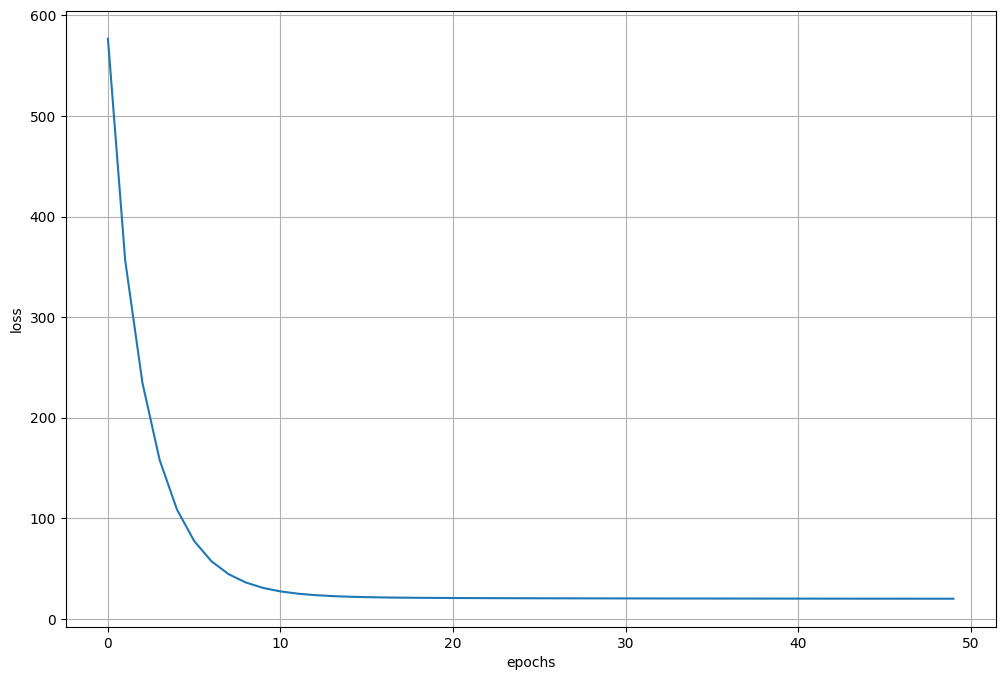

In [23]:
%matplotlib inline
from matplotlib import pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(losses)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.show()

In [24]:
# Iniziamo calcolando le predizioni del modello dati i pesi allineati
yt = linear_regression(X_testing_norm, theta, theta_0)

# Calcoliamo il valore della loss
print(loss(yt, Y_testing))

tensor(42.8972, grad_fn=<MeanBackward0>)


In [25]:
lr = 0.1
epochs = 50

# Passo 1: normalizzazione dei dati
means = X_training.mean(0)
stds = X_training.std(0)

X_training_norm = (X_training-means)/stds
X_testing_norm = (X_testing-means)/stds

# Passo 2: inizializziamo i pesi come visto in precedenza
theta = torch.Tensor(13)
theta_0 = torch.Tensor(1)
theta.normal_(0,0.01)
theta_0.normal_(0,0.01)

theta.requires_grad_(True)
theta_0.requires_grad_(True)

losses_train = []
losses_test = []

for e in range(epochs) :
    # Passo 3: calcoliamo le predizioni
    y = linear_regression(X_training_norm, theta, theta_0)

    # Passo 4: calcoliamo il valore della loss
    l = loss(y, Y_training)

    # Passo 5: calcoliamo il gradiente della loss rispetto a tutti i parametri
    l.backward()

    # Conserviamo il valore della loss di training
    losses_train.append(l.item())

    # Passo 6: aggiorniamo i pesi
    theta.data.sub_(lr*theta.grad.data)
    theta_0.data.sub_(lr*theta_0.grad.data)

    # Azzeriamo i gradienti per evitare di accumularli
    theta.grad.data.zero_()
    theta_0.grad.data.zero_()

    # Calcoliamo la loss sul test set
    # dato che non dobbiamo calcolare i gradienti
    # li disabilitiamo per risparmiare memoria
    with torch.set_grad_enabled(False) :
        y_test = linear_regression(X_testing_norm, theta, theta_0)
        loss_test = loss(y_test, Y_testing)
        losses_test.append(loss_test.item())

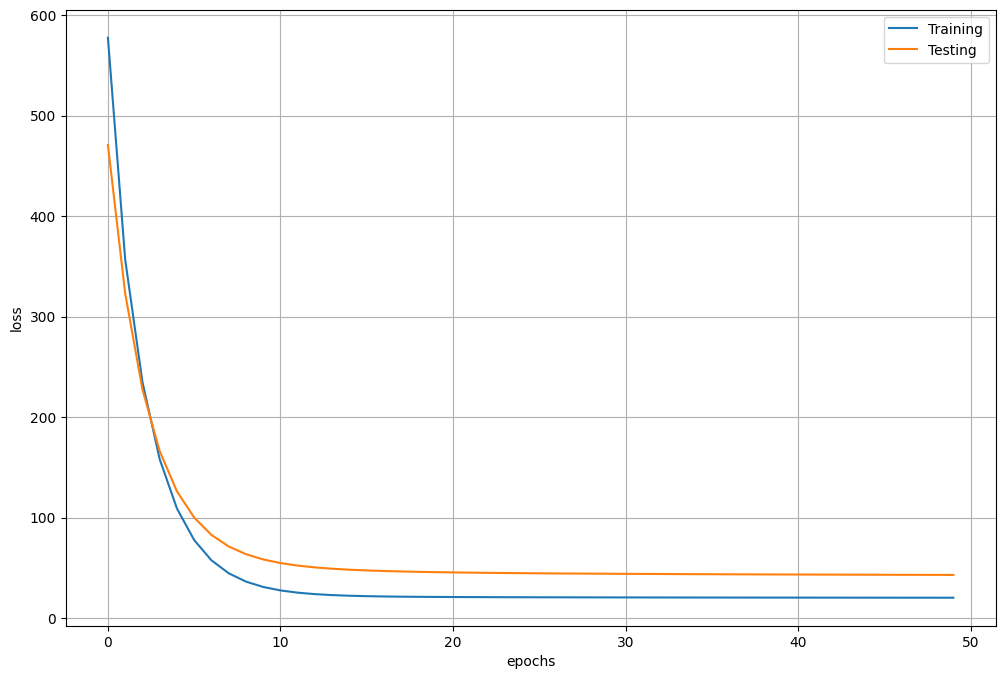

In [26]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(losses_train)
plt.plot(losses_test)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.legend(['Training','Testing'])
plt.show()

In [27]:
from torch import nn

linear = nn.Linear(20,10)

In [28]:
par = list(linear.parameters())
print(par[0].shape) # Matrice A [m x n]
print(par[1].shape) # Vettore b [m]

torch.Size([10, 20])
torch.Size([10])


In [29]:
# Costruiamo una matrice di 150 elementi a 20 dimensioni
sample_input = torch.rand((150,20))

# Otteniamo una matrice di 150 elementi a 10 dimensioni
sample_output = linear(sample_input)
print(sample_output.shape)

torch.Size([150, 10])


In [30]:
linreg = nn.Linear(13,1)
z = linreg(X_training_norm)
print(z.shape)

torch.Size([456, 1])


In [31]:
mse = nn.MSELoss()

In [32]:
print("Loss di Pytorch:", mse(z,Y_training.view(-1,1)))
print("Loss implementata a mano:", loss(z,Y_training.view(-1,1)))

Loss di Pytorch: tensor(571.1404, grad_fn=<MseLossBackward0>)
Loss implementata a mano: tensor(571.1404, grad_fn=<MeanBackward0>)


In [33]:
class LinearRegressor(nn.Module) :
    def __init__(self, in_size, out_size) :
        """Costruisce un regressore logistico.
            Input:
                in_size: numero di feature in input (es. 13)
                out_size: numero di elementi in output (es. 1)"""
        super(LinearRegressor, self).__init__()

        self.linear = nn.Linear(in_size, out_size)

    def forward (self, x) :
        """Definisce come processare l'input x"""
        result = self.linear(x)

        return result

In [34]:
reg = LinearRegressor(13,1)
print(list(reg.parameters()))

[Parameter containing:
tensor([[ 0.0483, -0.1044,  0.2277, -0.1250, -0.0252,  0.0191,  0.0361,  0.0599,
          0.2045, -0.0315, -0.1016,  0.0996, -0.2652]], requires_grad=True), Parameter containing:
tensor([-0.0121], requires_grad=True)]


In [35]:
lr = 0.1
epochs = 100

# Normalizzazione dei dati
means = X_training.mean(0)
stds = X_training.std(0)

X_training_norm = (X_training-means)/stds
X_testing_norm = (X_testing-means)/stds

reg = LinearRegressor(13,1)
criterion = nn.MSELoss() # la loss è spesso riferita come "criterio" di ottimizzazione

# l'optimizer vuole un riferimento ai parametri da ottimizzare e il learning rate
optimizer = torch.optim.SGD(reg.parameters(),lr=lr)

losses_train = []
losses_test = []

for e in range(epochs) :
    # mettiamo il regressore in modalità training
    reg.train()
    output = reg(X_training_norm)
    l = criterion(output.view(-1),Y_training)
    losses_train.append(l.item())

    l.backward()

    optimizer.step()
    optimizer.zero_grad()

    # calcoliamo la loss di test
    # mettiamo il modello in modalità validation
    reg.eval()

    with torch.set_grad_enabled(False) :
        y_test = reg(X_testing_norm)
        l = criterion(y_test.view(-1),Y_testing)
        losses_test.append(l.item())

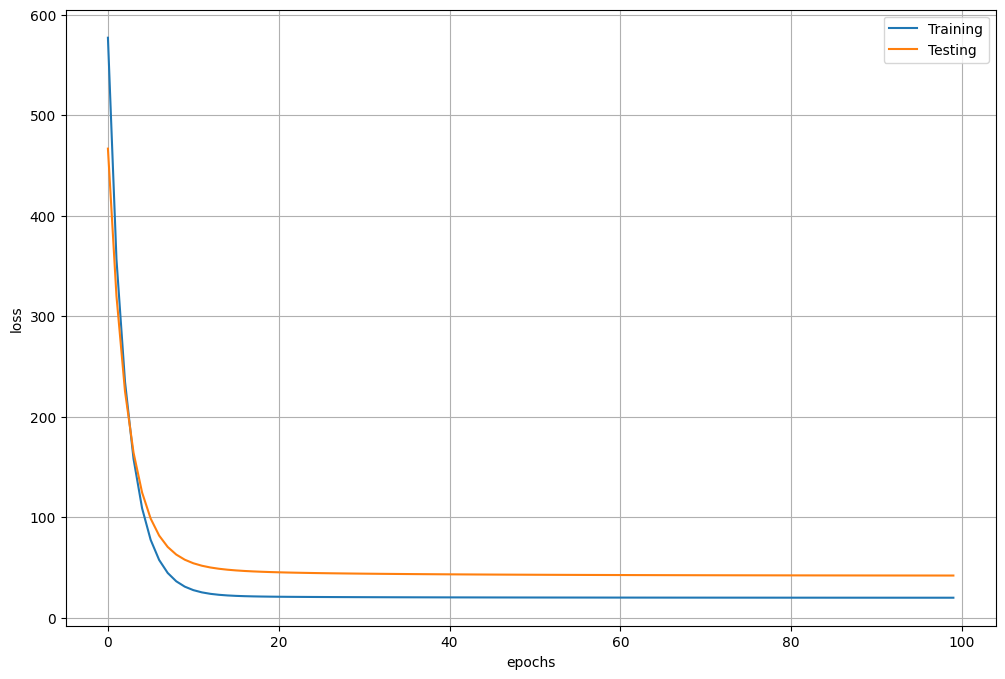

In [36]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(losses_train)
plt.plot(losses_test)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.legend(['Training','Testing'])
plt.show()

In [37]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('logs/test0')

In [38]:
# simuliamo un ciclo di training
for global_step in range(10) :
    writer.add_scalar('loss/train', np.sin(global_step/5*3.14), global_step=global_step)

# simuliamo un valore di test
writer.add_scalar('loss/test', 1, global_step=global_step)

# simuliamo un secondo ciclo di training
for global_step in range(10,20) :
    writer.add_scalar('loss/train', np.sin(global_step/5*3.14), global_step=global_step)

# simuliamo un secondo valore di test
writer.add_scalar('loss/test', 0.5, global_step=global_step)

In [39]:
# simuliamo un ciclo di training
for global_step in range(20,30) :
    writer.add_scalar('loss/train', np.sin(global_step/5*3.14), global_step=global_step)

# simuliamo un valore di test
writer.add_scalar('loss/test', 1, global_step=global_step)

# simuliamo un secondo ciclo di training
for global_step in range(30,40) :
    writer.add_scalar('loss/train', np.sin(global_step/5*3.14), global_step=global_step)

# simuliamo un secondo valore di test
writer.add_scalar('loss/test', 0.5, global_step=global_step)

In [40]:
lr = 0.01
# facciamo training per 5000 epoche in modo da verificare che tensorboard viene aggiornato in tempo reale
epochs = 5000

writer = SummaryWriter('logs/linear_regressor')

# normalizzazione dei dati
means = X_training.mean(0)
stds = X_training.std(0)

X_training_norm = (X_training-means)/stds
X_testing_norm = (X_testing-means)/stds

reg = LinearRegressor(13,1)
criterion = nn.MSELoss()

optimizer = torch.optim.SGD(reg.parameters(),lr=lr)

for e in range(epochs) :
    reg.train()
    output = reg(X_training_norm)
    l = criterion(output.view(-1),Y_training)

    writer.add_scalar('loss/train', l.item(), global_step=e)

    l.backward()

    optimizer.step()
    optimizer.zero_grad()

    reg.eval()

    with torch.set_grad_enabled(False) :
        y_test = reg(X_testing_norm)
        l = criterion(y_test.view(-1),Y_testing)
        writer.add_scalar('loss/test', l.item(), global_step=e)

In [41]:
lr = 0.001
# facciamo training per 5000 epoche in modo da verificare che tensorboard viene aggiornato in tempo reale
epochs = 5000

writer = SummaryWriter('logs/linear_regressor_lr0001')

# normalizzazione dei dati
means = X_training.mean(0)
stds = X_training.std(0)

X_training_norm = (X_training-means)/stds
X_testing_norm = (X_testing-means)/stds

reg = LinearRegressor(13,1)
criterion = nn.MSELoss()

optimizer = torch.optim.SGD(reg.parameters(),lr=lr)

for e in range(epochs) :
    reg.train()
    output = reg(X_training_norm)
    l = criterion(output.view(-1),Y_training)

    writer.add_scalar('loss/train', l.item(), global_step=e)

    l.backward()

    optimizer.step()
    optimizer.zero_grad()

    reg.eval()

    with torch.set_grad_enabled(False) :
        y_test = reg(X_testing_norm)
        l = criterion(y_test.view(-1),Y_testing)
        writer.add_scalar('loss/test', l.item(), global_step=e)